<a href="https://colab.research.google.com/github/jorgevillegazz/Estadisticas-y-Machine-Learning-G9---ONE/blob/main/Clasificacion_validacion_y_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='dark'>**Clasificación: Validación de modelos y métricas de evaluación**</h1>

### Proyecto

Una empresa de financiamiento de automóviles está atravesando una situación complicada, con una alta demanda para una flota reducida de vehículos y un alto número de morosos, lo que está generando grandes pérdidas para la empresa.

Nosotros fuimos contratados para buscar mejoras en la identificación de morosos. El análisis de los clientes actualmente se realiza de forma manual, cliente por cliente, lo que consume mucho tiempo y, aun así, la detección de morosos es muy imprecisa.

Nuestra tarea es utilizar los datos proporcionados por la empresa para **clasificar** a los clientes en cumplidores y morosos.

## <font color='dark'>Clasificando los datos</h1>

### Creando un modelo inicial

In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv('/content/prestacar.csv')

In [4]:
datos

,ingresos_cliente,anualidad_prestamo,años_casa_propia,telefono_trab,evaluacion_ciudad,score_1,score_2,score_3,score_social,cambio_telefono,moroso
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [7]:
X = datos.drop(columns='moroso', axis=1)
y = datos['moroso']

In [9]:
X

,ingresos_cliente,anualidad_prestamo,años_casa_propia,telefono_trab,evaluacion_ciudad,score_1,score_2,score_3,score_social,cambio_telefono
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000
...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000


In [10]:
y

,moroso
0,0
1,0
2,0
3,0
4,0
...,...
54020,1
54021,1
54022,1
54023,1


In [11]:
from sklearn.tree import DecisionTreeClassifier
modelo = DecisionTreeClassifier()
modelo.fit(X,y)
modelo.score(X,y)

1.0

In [12]:
print(f'La Exactitud del modelo es :{modelo.score(X,y)}')

La Exactitud del modelo es :1.0


### Validando el modelo

Evaluar el modelo con los mismos datos utilizados en el entrenamiento no es recomendable. Es necesario que la evaluación se realice con datos independientes.  

Evaluar el modelo con los propios datos de entrenamiento sería equivalente a entregar un examen con las preguntas y las respuestas a una persona y, al momento de evaluarla nuevamente, entregarle un examen con las mismas preguntas y opciones. Se espera que esa persona obtenga un buen resultado, ya que ya ha visto las respuestas y ha memorizado el resultado. Esto es diferente de haber aprendido la materia a partir de ese examen y luego presentar una prueba con contenido similar y obtener un resultado positivo.  

**La buena práctica** cuando trabajamos con Machine Learning **es tener tres conjuntos de datos**.

Con el objetivo de verificar la capacidad de generalización de un modelo, debemos dividir el conjunto de datos en tres partes: datos de entrenamiento, validación y prueba. Podríamos hablar de dos conjuntos: uno compuesto por un conjunto de prueba y el otro conjunto compuesto por el conjunto de entrenamiento y el conjunto de validación.  

- El **conjunto de entrenamiento** se utiliza para entrenar los modelos. A partir de este conjunto, los modelos identifican patrones en los datos.  

- El **conjunto de validación** se emplea para evaluar el desempeño de diferentes modelos con datos nuevos que no fueron utilizados en el entrenamiento.  

- El **conjunto de prueba** se mantiene separado desde el inicio para simular datos del mundo real. No se utiliza en ninguna etapa del entrenamiento ni de la validación, sirviendo como una estimación de la capacidad del modelo elegido para generalizar y predecir nuevos datos.

<a href="https://ibb.co/9H2Z1HZ5"><img src="https://i.ibb.co/0yZs6ysb/datos-train-test.png" alt="datos-train-test" border="0"></a>

In [13]:
from sklearn.model_selection import train_test_split

En nuestro caso, vamos a hacer primero la separación para el entrenamiento y validación y para prueba, y después vamos a hacer la separación de entrenamiento y validación efectivamente

---

¿Cómo lo hacemos? Vamos a tomar nuestra X, nuestra X, Test, vamos a tomar nuestra Y y nuestra Y, Test que van a ser los de prueba y vamos a hacer lo siguiente Train, Test, Split. Vamos a introducirle nuestra X, nuestra Y, vamos a tomar una base de prueba Test, Size del 15%, 0.15 y vamos a utilizar el método Stratify.

¿Cuál es el objetivo de hacer este Stratify? Que deje la misma cantidad de observaciones para morosos en los dos conjuntos de datos que estoy separando. ¿Qué quiere decir ello? Que si en mi conjunto de prueba tengo un 10% de morosos, también quiero que en mi conjunto de entrenamiento y validación exista un 10% de morosos. Entonces, esa es la idea y vamos a hacer este Stratify utilizando nuestra Y.

Por último, vamos a establecer un estado de aleatoriedad RandomState y vamos a darle el número 5. El estado de aleatoriedad básicamente nos permite replicar esta misma división en cualquier momento, es decir, la forma en que voy a dividir mis muestras en este ejercicio podrá replicarse en cualquier máquina, porque siempre que utilice el RandomState 5 él va a dividir de la misma manera, por eso se llama un estado de pseudo aleatoriedad.

In [14]:
X,X_test,y,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=5)

Ahora vamos a hacer lo mismo pero para la validación. Entonces, vuelvo y tomo mi nueva X y mi nueva Y, ¿verdad? Y en vez de XTEST aquí voy a llamar XVAL y YVAL, ¿ok?

Y aquí, en lugar de dejarlo como X, lo voy a cambiar a XTRAIN y en lugar de dejar Y así, lo voy a cambiar a YTRAIN. De esta manera, ya segmento mis datos para entrenamiento y para prueba. No voy a especificar el tamaño de la prueba porque por defecto es el 25%. Si observas aquí, indica que cuando no se aplica un tamaño de prueba, se configura al 25%, así que lo dejaré así, ¿de acuerdo? Y el resto permanece igual. Entonces, ejecutamos nuestra celda.

In [15]:
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

Ahora ya tenemos nuestra X de entrenamiento, nuestra X de validación, nuestra Y de entrenamiento y nuestra Y de validación. Perfecto. Vamos a instanciar de nuevo nuestro modelo

Modelo es igual a DECISIONTREE CLASSIFIER sin ningún parámetro. No es una buena práctica, pero vamos a avanzar en ello y vamos a hacer MODELO.FIT, ¿de acuerdo? Y vamos a hacer el FIT de XTRAIN y YTRAIN. Entonces, XTRAIN y YTRAIN. ¿Listo? Y vamos a calcular la exactitud.

La exactitud del modelo tanto para validación como para prueba

In [16]:
modelo = DecisionTreeClassifier()
modelo.fit(X_train,y_train)
print(f'La Exactitud del modelo del conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La Exactitud del modelo del conjunto de validación  es de: {modelo.score(X_val,y_val)}')

La Exactitud del modelo del conjunto de entrenamiento es de: 1.0
La Exactitud del modelo del conjunto de validación  es de: 0.8480968556745928


Observa que durante el entrenamiento, ¿verdad? Llegó al 100%, ¿de acuerdo? Y a la hora de validar, llegó al 84%. ¿Qué significa esto? Que mi modelo de árbol se memorizó completamente todas las salidas y por eso llegó al 100% y al momento de colocar datos que no ha visto, al momento de validarlo, entonces llegó al 84%. **Esta no es la mejor forma de instanciar un modelo de árbol de decisión**, sino que debemos establecer una profundidad al menos.

Entonces voy a colocar MAXDEPTH igual a 10, es decir, que baje 10 porque si no le coloco profundidad, se va a ir hasta el final. Por eso es que llega al 100%, ¿de acuerdo? Entonces es simplemente colocar ese MAXDEPTH y ejecutamos nuestra celda.

In [17]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train,y_train)
print(f'La Exactitud del modelo del conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La Exactitud del modelo del conjunto de validación  es de: {modelo.score(X_val,y_val)}')

La Exactitud del modelo del conjunto de entrenamiento es de: 0.9205865272938444
La Exactitud del modelo del conjunto de validación  es de: 0.9061057399181256


Y ahora observa que ya con este parámetro, durante mi entrenamiento llegó a un 92% y la exactitud del modelo al momento de validarlo fue el 90%. ¿Cuál es la conclusión aquí? Está generalizando mejor. ¿Por qué? Porque no se está memorizando todas las salidas y únicamente ajustamos un parámetro, ¿de acuerdo? Entonces aquí ya comenzamos a encontrar el camino para poder hacer nuestra validación del modelo, pero ahora también nos falta evaluarlo

# **Para saber más: método holdout**


En el momento de validar modelos de clasificación, necesitamos verificar si el modelo está realmente generalizando, es decir, si está comprendiendo el patrón de los datos y clasificando correctamente datos nuevos. La estrategia más simple para evaluar esta generalización, conocida como holdout, consiste en dividir los datos en dos partes: un conjunto de datos de entrenamiento y otro de prueba. El conjunto de entrenamiento se utiliza para entrenar el modelo, mientras que el conjunto de prueba se usa para evaluar el rendimiento del modelo en datos no vistos anteriormente.

Con la ayuda de la imagen a continuación, analiza la ejemplificación del método holdout en funcionamiento:

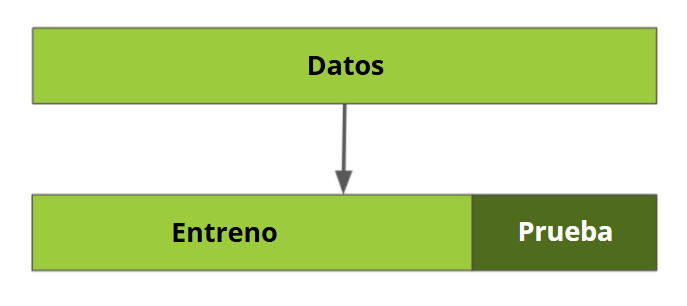

En algunos casos, especialmente cuando se realizan ajustes finos en los parámetros del modelo, es útil tener un conjunto de validación adicional. En este caso, la división se hace en tres partes: conjunto de entrenamiento, conjunto de validación y conjunto de prueba. El conjunto de validación se utiliza en la comparación de diferentes modelos, en la selección del modelo más adecuado y en el ajuste de los hiperparámetros. Mientras tanto, el conjunto de prueba sigue utilizándose para evaluar el rendimiento final del modelo elegido, después de todo el proceso de ajuste.

Por eso, cuanto más se utilizan los mismos datos para tomar decisiones sobre configuraciones de mejoras en el modelo o elección de hiperparámetros, más comprometida se vuelve la confiabilidad de esos resultados al ser generalizados para datos nuevos y no vistos. Esto ocurre porque las mejoras se hacen a partir de esos datos de validación.

Es posible percibir que las mejoras aplicadas desempeñan un papel fundamental para resolver el problema. Sin embargo, para asegurar que el rendimiento del modelo permanezca consistente en relación a los datos del mundo real, que no fueron vistos en el entrenamiento o en la mejora de los modelos, la estrategia de la división entre 3 conjuntos de datos, como se puede analizar en la imagen siguiente, ofrece una buena dirección final, ya que indica si el modelo elegido está sesgado o no en relación a los datos de validación.

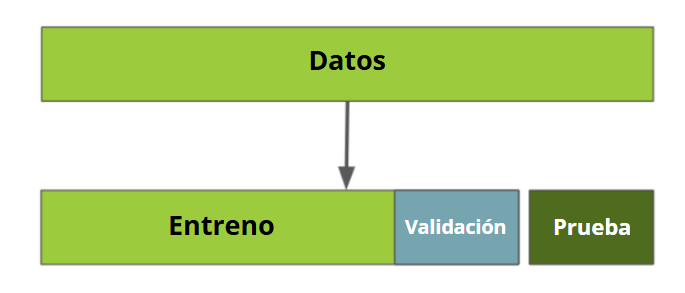

### Evaluando el modelo

Ya hemos generado la validación de nuestro modelo y obtenido una puntuación de precisión. En uno de los casos, no limitamos nuestro árbol de decisión, por lo que llegó hasta el final. Obtuvo un 100% en el entrenamiento, pero al momento de validar, como también aprendió los datos del entrenamiento, tuvo este resultado en precisión.

En el otro caso, establecimos un Max Depth de 10, e introdujimos nuevamente nuestra X de entrenamiento y nuestra Y de entrenamiento. El modelo, una vez entrenado, alcanzó una precisión del 92% y al momento de validarlo, una precisión del 90%. Es decir, estos valores están más cercanos.

Sin embargo, ¿qué significa precisión? Significa que en el 90% de los casos, mi modelo generalizó bien, por ejemplo, para este caso en la validación. Pero, ¿qué generalizó bien? Es decir, en el 90% de los casos, ¿qué sucedió? ¿Identificó cuántos deudores o cuántos clientes cumplidos? No tenemos esta visibilidad en este punto.

Por lo tanto, la precisión es una métrica que no nos dice mucho. Nos indica si el modelo está generalizando bien o no, pero no conocemos en detalle qué es lo que está generalizando y si es de nuestro interés. Para ello, vamos a utilizar también una herramienta para validar nuestros modelos, que es la **matriz de confusión.**

In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
y_previsto = modelo.predict(X_val)
matriz_confucion = confusion_matrix(y_val, y_previsto)
print(matriz_confucion)

[[10362   117]
 [  961    41]]


## <font color='dark'>Métricas de evaluación</h1>

### Exactitud, precisión y recall (sensibilidad).

<a href="https://ibb.co/351SbY7t"><img src="https://i.ibb.co/wZypqrRD/matriz-confusion.png" alt="matriz-confusion" border="0"></a>

<a href="https://imgbb.com/"><img src="https://i.ibb.co/6Jp6rKyC/Captura-de-tela-2025-03-22-120744.png" alt="Captura-de-tela-2025-03-22-120744" border="0"></a>

### Curva ROC

In [ ]:
from IPython.display import Image
Image(url='https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/cutoff.gif')

Fuente: [paulvanderlaken.com](https://paulvanderlaken.com/2019/08/16/roc-auc-precision-and-recall-visually-explained/)




### Curva de  precisión x sensibilidad

In [ ]:
Image(url='https://paulvanderlaken.com/wp-content/uploads/2019/08/roc.gif')

Fuente: [paulvanderlaken.com](https://paulvanderlaken.com/2019/08/16/roc-auc-precision-and-recall-visually-explained/)


### Informe de métricas

## <font color='dark'> Validación cruzada</h1>

### Usando KFold

La validación del modelo de clasificación a partir de la separación de los datos en conjuntos de entrenamiento y validación hace que el resultado dependa en gran medida de esta división. Puede suceder que, de forma aleatoria, el patrón de los datos de validación sea diferente al de los datos de entrenamiento, lo que podría llevar a obtener un resultado mucho mejor o mucho peor que la realidad simplemente por suerte o mala suerte.  

Teniendo esto en cuenta, es posible utilizar la **validación cruzada**, una estrategia más consistente y ampliamente utilizada en proyectos de *machine learning*.  

En la validación cruzada, en lugar de separar los datos en entrenamiento y validación una sola vez, se dividen en varias partes de igual tamaño. En cada una de estas divisiones, se usa una parte para validación y todas las demás para entrenamiento. Este proceso se repite hasta que todas las partes hayan sido utilizadas tanto para validación como para entrenamiento.  

Se generará un modelo para cada una de estas divisiones y la evaluación del desempeño se realizará promediando la métrica de cada modelo. Esto elimina la dependencia de la separación de los datos, ya que hay una mayor variación en la selección de los mismos y se obtiene un valor medio.  

Generalmente, se utilizan 5 o 10 partes. Un número mayor no suele ser necesario, ya que implica un procesamiento más costoso, y valores menores ya ayudan a mitigar el problema de la selección de los datos.

<a href="https://ibb.co/KcBtshJR"><img src="https://i.ibb.co/nq4X1mFZ/train-y-validacion.png" alt="train-y-validacion" border="0"></a>

### Validación cruzada con sensibilidad

### Estratificando los datos

## <font color='dark'>Balanceo de los datos</h1>

### Oversampling

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html#id1

### Pipeline para validación

### Undersampling

https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.NearMiss.html

### Probando el modelo